# Alpaca Demo

In [19]:
# Initial imports
import os
import requests
import pandas as pd
from dotenv import load_dotenv
import alpaca_trade_api as tradeapi

%matplotlib inline

In [2]:
# Load .env environment variables
load_dotenv()

True

In [3]:
# Set Alpaca API key and secret
alpaca_api_key = os.getenv("ALPACA_API_KEY")
alpaca_secret_key = os.getenv("ALPACA_SECRET_KEY")

In [4]:
# Verify that Alpaca key and secret were correctly loaded
print(f"Alpaca Key type: {type(alpaca_api_key)}")
print(f"Alpaca Secret Key type: {type(alpaca_secret_key)}")

Alpaca Key type: <class 'str'>
Alpaca Secret Key type: <class 'str'>


In [5]:
# Create the Alpaca API object
alpaca = tradeapi.REST(
    alpaca_api_key,
    alpaca_secret_key,
    api_version="v2")

In [6]:
# Format current date as ISO format
today = pd.Timestamp("2020-07-14", tz="America/New_York").isoformat()

In [7]:
# Set the tickers
tickers = ["FB", "TWTR"]

In [8]:
# Set timeframe to one day ("1Day") for the Alpaca API
timeframe = "1Day"

In [9]:
# Get current closing prices for FB and TWTR
df_portfolio = alpaca.get_bars(
    tickers,
    timeframe,
    start = today,
    end = today
).df

# Display sample data
df_portfolio

,close,high,low,trade_count,open,volume,vwap,symbol
timestamp,,,,,,,,
2020-07-14 04:00:00+00:00,239.73,240.33,232.03,244837,236.76,24922768,237.123308,FB
2020-07-14 04:00:00+00:00,34.38,34.66,33.44,96661,33.53,21588413,34.187190,TWTR


In [10]:
# Format start and end dates as ISO format for one year period
start = pd.Timestamp("2019-07-14", tz="America/New_York").isoformat()
end = pd.Timestamp("2020-07-14", tz="America/New_York").isoformat()

In [11]:
# Get closing prices for FB and TWTR from the last year
df_portfolio_year = alpaca.get_bars(
    tickers,
    timeframe,
    start = start,
    end = end
).df

# Display sample data
df_portfolio_year.head(10)

,close,high,low,trade_count,open,volume,vwap,symbol
timestamp,,,,,,,,
2019-07-15 04:00:00+00:00,203.91,205.3300,201.8200,144229,204.25,16972563,203.871252,FB
2019-07-16 04:00:00+00:00,203.84,205.4707,203.1000,107939,203.89,12682328,204.123233,FB
2019-07-17 04:00:00+00:00,201.80,204.3600,201.5900,112850,204.18,13172182,202.498845,FB
2019-07-18 04:00:00+00:00,200.78,202.4700,199.3800,111377,200.15,12719444,200.623803,FB
2019-07-19 04:00:00+00:00,198.36,202.3300,198.0700,102977,202.18,13597320,200.086825,FB
2019-07-22 04:00:00+00:00,202.32,202.5700,198.8100,120169,199.91,14522116,201.301601,FB
2019-07-23 04:00:00+00:00,202.36,204.2420,200.9625,123223,202.84,15469348,202.229324,FB
2019-07-24 04:00:00+00:00,204.66,204.8100,197.2200,271250,197.63,33959225,203.377692,FB
2019-07-25 04:00:00+00:00,200.71,208.6600,198.2600,341775,206.70,41465948,201.530117,FB


In [12]:
# Reorganize the DataFrame

# Separate ticker data
FB = df_portfolio_year[df_portfolio_year['symbol']=='FB'].drop('symbol', axis=1)
TWTR = df_portfolio_year[df_portfolio_year['symbol']=='TWTR'].drop('symbol', axis=1)

# Concatenate the ticker DataFrames
df_portfolio_year = pd.concat([FB, TWTR],axis=1, keys=['FB','TWTR'])

# Display sample data
df_portfolio_year

FB                                         \
                            close      high     low trade_count     open   
timestamp                                                                  
2019-07-15 04:00:00+00:00  203.91  205.3300  201.82      144229  204.250   
2019-07-16 04:00:00+00:00  203.84  205.4707  203.10      107939  203.890   
2019-07-17 04:00:00+00:00  201.80  204.3600  201.59      112850  204.180   
2019-07-18 04:00:00+00:00  200.78  202.4700  199.38      111377  200.150   
2019-07-19 04:00:00+00:00  198.36  202.3300  198.07      102977  202.180   
...                           ...       ...     ...         ...      ...   
2020-07-08 04:00:00+00:00  243.58  246.9900  236.59      290457  238.110   
2020-07-09 04:00:00+00:00  244.50  246.5250  239.24      238903  245.000   
2020-07-10 04:00:00+00:00  245.07  245.4900  239.32      235685  243.685   
2020-07-13 04:00:00+00:00  239.00  250.1500  238.42      260453  247.005   
2020-07-14 04:00:00+00:00  239.73  240.3300  232.03      244837  236.760   

                                                  TWTR                   \
                             volume        vwap  close    high      low   
timestamp                                                                 
2019-07-15 04:00:00+00:00  16972563  203.871252  38.68  38.970  37.9435   
2019-07-16 04:00:00+00:00  12682328  204.123233  37.99  38.790  37.8200   
2019-07-17 04:00:00+00:00  13172182  202.498845  37.70  38.230  37.5600   
2019-07-18 04:00:00+00:00  12719444  200.623803  37.66  37.795  37.0000   
2019-07-19 04:00:00+00:00  13597320  200.086825  36.77  38.090  36.7300   
...                             ...         ...    ...     ...      ...   
2020-07-08 04:00:00+00:00  30845743  241.550607  35.41  36.980  32.7300   
2020-07-09 04:00:00+00:00  23251056  243.319075  35.72  36.180  34.8100   
2020-07-10 04:00:00+00:00  24255049  242.948904  35.40  35.760  34.8600   
2020-07-13 04:00:00+00:00  25838800  245.244680  33.82  36.210  33.7600   
2020-07-14 04:00:00+00:00  24922768  237.123308  34.38  34.660  33.4400   

                                                                    
                          trade_count   open     volume       vwap  
timestamp                                                           
2019-07-15 04:00:00+00:00       59645  37.99   13557714  38.544378  
2019-07-16 04:00:00+00:00       51228  38.79   11821056  38.161755  
2019-07-17 04:00:00+00:00       40226  37.86    8313414  37.820894  
2019-07-18 04:00:00+00:00       52884  37.39   12023603  37.457475  
2019-07-19 04:00:00+00:00       50926  37.96   11650156  37.180041  
...                               ...    ...        ...        ...  
2020-07-08 04:00:00+00:00      418559  33.20  115581705  35.447919  
2020-07-09 04:00:00+00:00      137867  35.86   39872447  35.636622  
2020-07-10 04:00:00+00:00       84968  35.48   15648977  35.181453  
2020-07-13 04:00:00+00:00      103833  35.72   23136960  34.812845  
2020-07-14 04:00:00+00:00       96661  33.53   21588413  34.187190  

[253 rows x 14 columns]

In [13]:
alpaca

In [14]:
df_portfolio_year.tail(10)

FB                                        \
                            close     high     low trade_count     open   
timestamp                                                                 
2020-06-30 04:00:00+00:00  227.07  227.500  218.47      317097  220.590   
2020-07-01 04:00:00+00:00  237.55  239.000  227.56      400708  228.500   
2020-07-02 04:00:00+00:00  233.42  240.000  232.61      298885  239.000   
2020-07-06 04:00:00+00:00  240.28  240.400  232.27      256193  233.760   
2020-07-07 04:00:00+00:00  240.86  247.650  238.82      279311  239.410   
2020-07-08 04:00:00+00:00  243.58  246.990  236.59      290457  238.110   
2020-07-09 04:00:00+00:00  244.50  246.525  239.24      238903  245.000   
2020-07-10 04:00:00+00:00  245.07  245.490  239.32      235685  243.685   
2020-07-13 04:00:00+00:00  239.00  250.150  238.42      260453  247.005   
2020-07-14 04:00:00+00:00  239.73  240.330  232.03      244837  236.760   

                                                  TWTR                 \
                             volume        vwap  close   high     low   
timestamp                                                               
2020-06-30 04:00:00+00:00  36545919  223.675996  29.79  29.82  29.020   
2020-07-01 04:00:00+00:00  44722297  234.472715  30.81  31.17  30.060   
2020-07-02 04:00:00+00:00  32172154  235.400324  30.87  31.40  30.395   
2020-07-06 04:00:00+00:00  27654293  237.887672  32.34  32.81  31.155   
2020-07-07 04:00:00+00:00  29178588  243.568679  32.99  33.67  31.765   
2020-07-08 04:00:00+00:00  30845743  241.550607  35.41  36.98  32.730   
2020-07-09 04:00:00+00:00  23251056  243.319075  35.72  36.18  34.810   
2020-07-10 04:00:00+00:00  24255049  242.948904  35.40  35.76  34.860   
2020-07-13 04:00:00+00:00  25838800  245.244680  33.82  36.21  33.760   
2020-07-14 04:00:00+00:00  24922768  237.123308  34.38  34.66  33.440   

                                                                    
                          trade_count   open     volume       vwap  
timestamp                                                           
2020-06-30 04:00:00+00:00      103238  29.60   22446150  29.535539  
2020-07-01 04:00:00+00:00      117034  30.15   21512056  30.798863  
2020-07-02 04:00:00+00:00       79764  31.30   15272320  30.960376  
2020-07-06 04:00:00+00:00      112348  31.55   24580885  32.259104  
2020-07-07 04:00:00+00:00      117531  31.96   33043819  33.001911  
2020-07-08 04:00:00+00:00      418559  33.20  115581705  35.447919  
2020-07-09 04:00:00+00:00      137867  35.86   39872447  35.636622  
2020-07-10 04:00:00+00:00       84968  35.48   15648977  35.181453  
2020-07-13 04:00:00+00:00      103833  35.72   23136960  34.812845  
2020-07-14 04:00:00+00:00       96661  33.53   21588413  34.187190

In [15]:
# Create and empty DataFrame for closing prices
df_closing_prices = pd.DataFrame()

# Fetch the closing prices of FB and TWTR
df_closing_prices["FB"] = df_portfolio_year["FB"]["close"]
df_closing_prices["TWTR"] = df_portfolio_year["TWTR"]["close"]

# Drop the time component of the date
df_closing_prices.index = df_closing_prices.index.date

# Display sample data
df_closing_prices.head(10)

,FB,TWTR
2019-07-15,203.91,38.68
2019-07-16,203.84,37.99
2019-07-17,201.80,37.70
2019-07-18,200.78,37.66
2019-07-19,198.36,36.77
2019-07-22,202.32,37.58
2019-07-23,202.36,37.90
2019-07-24,204.66,38.73
2019-07-25,200.71,38.12
2019-07-26,199.75,41.52


In [16]:
# Compute daily returns
df_daily_returns = df_closing_prices.pct_change().dropna()

# Display sample data
df_daily_returns.head()

,FB,TWTR
2019-07-16,-0.000343,-0.017839
2019-07-17,-0.010008,-0.007634
2019-07-18,-0.005055,-0.001061
2019-07-19,-0.012053,-0.023633
2019-07-22,0.019964,0.022029


<AxesSubplot: title={'center': 'Daily Returns of FB and TWTR over the Last Year'}>

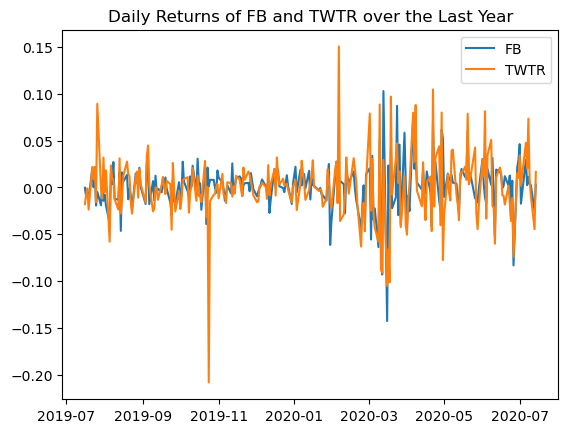

In [17]:
# Plot daily returns
df_daily_returns.plot(title="Daily Returns of FB and TWTR over the Last Year")